In [ ]:
import sklearn.datasets as sdt
import matplotlib.pyplot as plt

# Create surogate data
n_samples = 1000
n_features = 10
n_info = 5
n_targets = 3
noise = 10

x, y = sdt.make_regression(
    n_samples=n_samples,
    n_features=n_features,
    n_informative=n_info,
    n_targets=n_targets,
    noise=noise,
    random_state=42,
)
print(f"Shape of x: {x.shape}, Shape of y: {y.shape}")

Shape of x: (1000, 10), Shape of y: (1000, 3)


In [ ]:
from ptmelt.utils.preprocessing import get_normalizers
from sklearn.model_selection import train_test_split

x_normalizer, y_normalizer = get_normalizers(norm_type="standard", n_normalizers=2)

x_normalizer.fit(x)
y_normalizer.fit(y)

x_norm = x_normalizer.transform(x)
y_norm = y_normalizer.transform(y)

# Create train and test datasets
x_train, x_test, y_train, y_test = train_test_split(
    x_norm, y_norm, test_size=0.2, random_state=42
)
# Create the validation dataset from the test dataset
x_test, x_val, y_test, y_val = train_test_split(
    x_test, y_test, test_size=0.5, random_state=42
)

# Precompute the un-normalized data for later use
y_train_real = y_normalizer.inverse_transform(y_train)
y_test_real = y_normalizer.inverse_transform(y_test)
y_val_real = y_normalizer.inverse_transform(y_val)

In [ ]:
# Create PyTorch dataloaders for training, validation, and testing
from torch.utils.data import DataLoader, TensorDataset
import torch

batch_size = 32

dataset = TensorDataset(
    torch.from_numpy(x_train).float(), torch.from_numpy(y_train).float()
)
dataset_val = TensorDataset(
    torch.from_numpy(x_val).float(), torch.from_numpy(y_val).float()
)

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
dataloader_val = DataLoader(
    dataset_val, batch_size=batch_size, shuffle=True, pin_memory=True
)

In [4]:
from ptmelt.utils.evaluation import ensemble_predictions
from ptmelt.utils.hp_tuning import model_builder, run_ray_tune
from ptmelt.utils.statistics import compute_cwc, compute_picp


def validation_uq_metrics(model, config, train_loss, val_loss, epoch, device):
    pred_mean_val, pred_std_val = ensemble_predictions(
        model,
        x_val.copy(),
        y_normalizer=y_normalizer,
        unnormalize=True,
        n_iter=100,
        training=True,
    )
    return {
        "val_cwc": compute_cwc(y_val_real, pred_mean_val, pred_std_val),
        "val_picp": compute_picp(y_val_real, pred_mean_val, pred_std_val),
    }

## Quick Test

In [5]:
# test
import time
from torchinfo import summary

s_time = time.time()

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("Using CPU")

base_configs = {
    "loss_fn": "mse",
    "num_features": x_train.shape[1],
    "num_outputs": y_train.shape[1],
}

tune_configs = {
    "arch_type": "ann",
    "learning_rate": 1e-3,
    "act_fun": "relu",
    "dropout": 0.1,
    "input_dropout": 0.1,
    "batch_norm": False,
    "l2_reg": 0.0,
    # "node_list": [32, 32],
    "node_list": None,
    "max_depth": 2,
}

initial_configs = {**base_configs, **tune_configs}

model, optimizer, crit = model_builder(initial_configs)
print(summary(model, input_size=(batch_size, x_train.shape[1]), device=device))

model.fit(
    train_dl=dataloader,
    val_dl=dataloader_val,
    optimizer=optimizer,
    criterion=crit,
    num_epochs=200,
    device=device,
    verbose=True,
)

print(f"Elapsed time: {time.time() - s_time}")

Using CPU
Layer (type:depth-idx)                   Output Shape              Param #
ArtificialNeuralNetwork                  [32, 3]                   --
├─ModuleDict: 1-1                        --                        --
│    └─Dropout: 2-1                      [32, 10]                  --
│    └─DenseBlock: 2-2                   [32, 10]                  --
│    └─DefaultOutput: 2-3                [32, 3]                   --
│    │    └─Linear: 3-1                  [32, 3]                   33
│    │    └─Identity: 3-2                [32, 3]                   --
Total params: 33
Trainable params: 33
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00


 10%|█         | 21/200 [00:00<00:00, 203.76it/s]

Epoch 10, Loss: 0.7306, Val Loss: 0.8566, LR: 1.0000e-03
Epoch 20, Loss: 0.3298, Val Loss: 0.3247, LR: 1.0000e-03
Epoch 30, Loss: 0.1759, Val Loss: 0.1356, LR: 1.0000e-03
Epoch 40, Loss: 0.1175, Val Loss: 0.0749, LR: 1.0000e-03


 22%|██▏       | 44/200 [00:00<00:00, 215.01it/s]

Epoch 50, Loss: 0.1039, Val Loss: 0.0508, LR: 1.0000e-03


...

Epoch 110, Loss: 0.1092, Val Loss: 0.0268, LR: 1.0000e-03
Epoch 120, Loss: 0.1078, Val Loss: 0.0298, LR: 1.0000e-03
Epoch 130, Loss: 0.1128, Val Loss: 0.0257, LR: 1.0000e-03
Epoch 140, Loss: 0.1121, Val Loss: 0.0331, LR: 1.0000e-03
Epoch 150, Loss: 0.1092, Val Loss: 0.0288, LR: 1.0000e-03


 90%|█████████ | 180/200 [00:00<00:00, 219.47it/s]

Epoch 160, Loss: 0.1088, Val Loss: 0.0342, LR: 1.0000e-03
Epoch 170, Loss: 0.1124, Val Loss: 0.0358, LR: 1.0000e-03
Epoch 180, Loss: 0.1304, Val Loss: 0.0292, LR: 1.0000e-03
Epoch 190, Loss: 0.1176, Val Loss: 0.0345, LR: 1.0000e-03


100%|██████████| 200/200 [00:00<00:00, 218.20it/s]

Epoch 200, Loss: 0.1267, Val Loss: 0.0277, LR: 1.0000e-03
Elapsed time: 1.3039722442626953


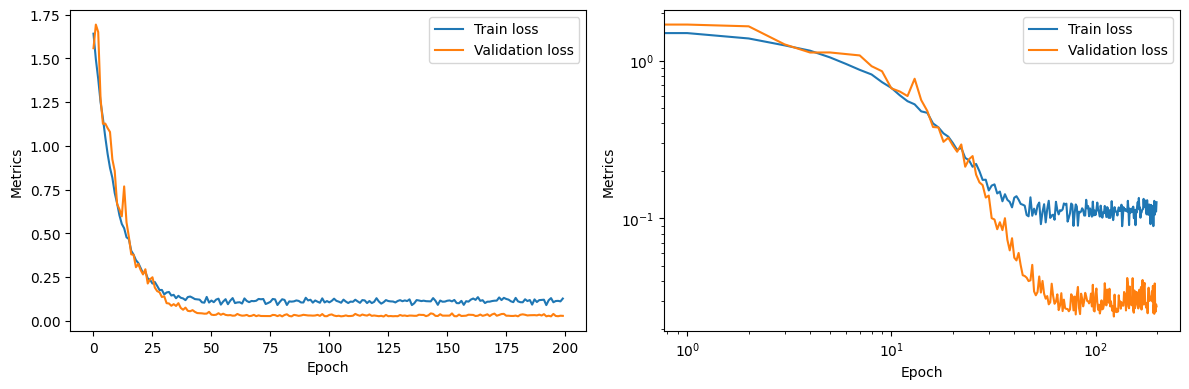

In [ ]:
from ptmelt.utils.visualization import plot_history

history = model.history
plot_history(history, plot_log=True)

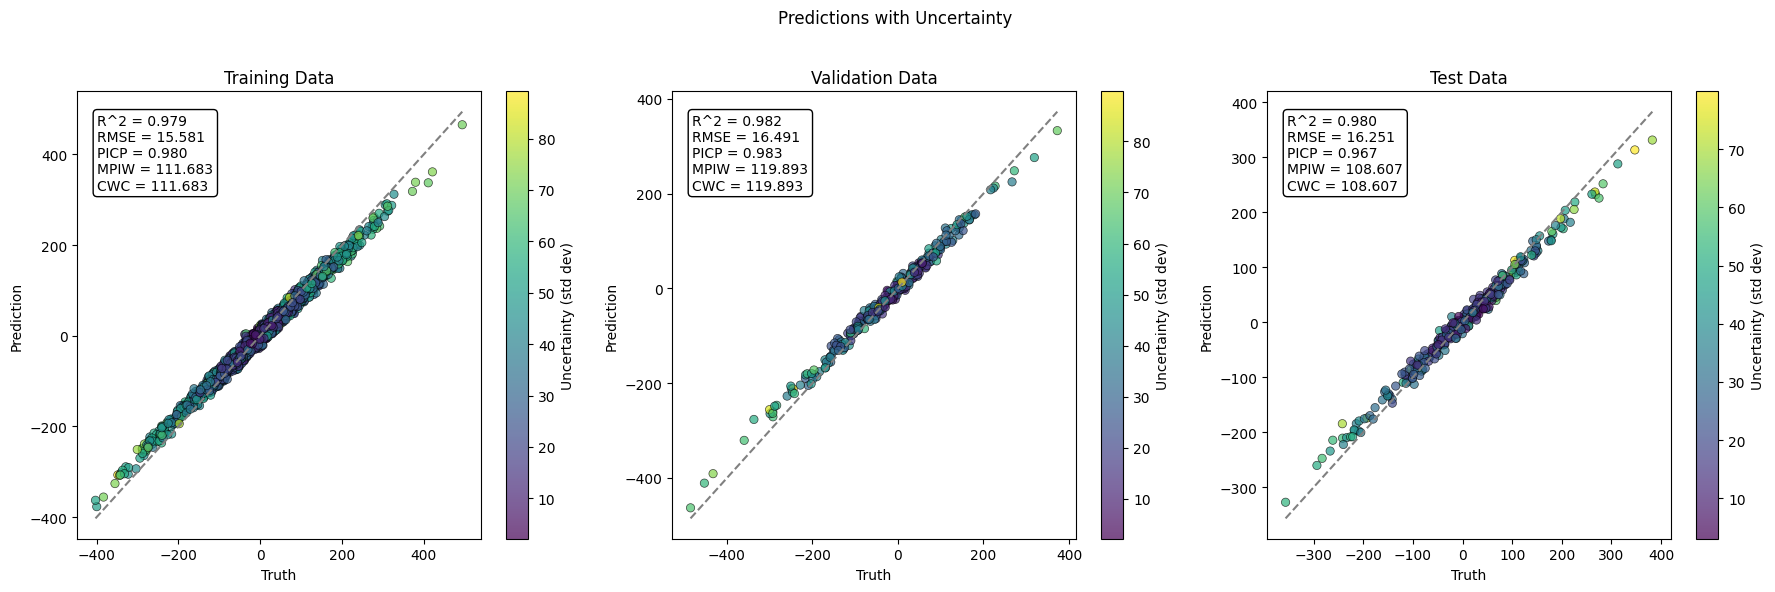

In [ ]:
from ptmelt.utils.evaluation import ensemble_predictions
from ptmelt.utils.visualization import plot_predictions_with_uncertainty

# Necessary to be consistent with pt-melt prediction routines
model.num_mixtures = 0
ensmeble_size = 100
training = True  # needed for monte carlo dropout evaluation
####

pred_mean_train, pred_std_train = ensemble_predictions(
    model,
    x_train,
    y_normalizer,
    unnormalize=True,
    n_iter=ensmeble_size,
    training=training,
)
pred_mean_test, pred_std_test = ensemble_predictions(
    model,
    x_test,
    y_normalizer,
    unnormalize=True,
    n_iter=ensmeble_size,
    training=training,
)
pred_mean_val, pred_std_val = ensemble_predictions(
    model,
    x_val,
    y_normalizer,
    unnormalize=True,
    n_iter=ensmeble_size,
    training=training,
)

plot_predictions_with_uncertainty(
    pred_mean_train,
    pred_std_train,
    y_train_real,
    pred_mean_val,
    pred_std_val,
    y_val_real,
    pred_mean_test,
    pred_std_test,
    y_test_real,
    metrics_to_display=["R^2", "RMSE", "PICP", "MPIW", "CWC"],
)

---
# Hyperparameter tuning
---

In [8]:
import numpy as np
from ray import tune

max_epochs = 50
num_samples = 20
reduction_factor = 3
grace_period = 5

base_configs = {
    "loss_fn": "mse",
    "num_features": x_train.shape[1],
    "num_outputs": y_train.shape[1],
    "epochs": max_epochs,
}

dropout_values = np.arange(0, 0.55, 0.05).tolist()
node_values = [0, 4, 8, 16, 32]
max_depth = 3

tune_configs = {
    "arch_type": "ann",
    "learning_rate": tune.choice([1e-3, 3e-4, 1e-4]),
    "act_fun": tune.choice(["relu", "tanh"]),
    "dropout": tune.choice(dropout_values),
    "input_dropout": tune.choice(dropout_values),
    "batch_norm": tune.choice([True, False]),
    "l2_reg": 0.0,
    **{f"layer_{i}_width": tune.choice(node_values) for i in range(max_depth)},
    "max_depth": max_depth,
    "node_list": None,
}

hpo_result = run_ray_tune(
    train_dl=dataloader,
    val_dl=dataloader_val,
    base_config=base_configs,
    search_space=tune_configs,
    metric="val_loss",
    mode="min",
    num_samples=num_samples,
    resources={"cpu": 1, "gpu": 0},
    scheduler="asha",
    scheduler_kwargs={
        "grace_period": grace_period,
        "reduction_factor": reduction_factor,
    },
    search_alg="optuna",
    max_concurrent=10,
    metric_fn=validation_uq_metrics,
    checkpoint_interval=grace_period,
    ray_init_kwargs={"ignore_reinit_error": True, "include_dashboard": False},
)

best_config = hpo_result.best_config
best_hyperparameters = hpo_result.best_hyperparameters
dfs = hpo_result.trial_history

print("Best config:", best_config)
print("Best searched hyperparameters:", best_hyperparameters)
print("Metric details:", hpo_result.metric_details)

(_ray_tune_trainable pid=2783) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/Users/nwimer/ray_results/_ray_tune_trainable_2026-06-12_14-58-44/_ray_tune_trainable_a65030c6_1_act_fun=tanh,arch_type=ann,batch_norm=False,dropout=0.3000,epochs=50,input_dropout=0.0000,l2_reg=0._2026-06-12_14-58-44/checkpoint_000000)
(_ray_tune_trainable pid=2783) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/Users/nwimer/ray_results/_ray_tune_trainable_2026-06-12_14-58-44/_ray_tune_trainable_a65030c6_1_act_fun=tanh,arch_type=ann,batch_norm=False,dropout=0.3000,epochs=50,input_dropout=0.0000,l2_reg=0._2026-06-12_14-58-44/checkpoint_000001)
(_ray_tune_trainable pid=2783) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/Users/nwimer/ray_results/_ray_tune_trainable_2026-06-12_14-58-44/_ray_tune_trainable_a65030c6_1_act_fun=tanh,arch_type=ann,batch_norm=False,dropout=0.3000,epochs=50,input_dropout=0.0000,l2_reg=0._2026-06-12_14-58-44/checkpoi

Best config: {'loss_fn': 'mse', 'num_features': 10, 'num_outputs': 3, 'epochs': 50, 'arch_type': 'ann', 'learning_rate': 0.001, 'act_fun': 'tanh', 'dropout': 0.25, 'input_dropout': 0.0, 'batch_norm': True, 'l2_reg': 0.0, 'layer_0_width': 4, 'layer_1_width': 32, 'layer_2_width': 8, 'max_depth': 3, 'node_list': None}
Best searched hyperparameters: {'arch_type': 'ann', 'learning_rate': 0.001, 'act_fun': 'tanh', 'dropout': 0.25, 'input_dropout': 0.0, 'batch_norm': True, 'l2_reg': 0.0, 'layer_0_width': 4, 'layer_1_width': 32, 'layer_2_width': 8, 'max_depth': 3, 'node_list': None}
Metric details: {'metric': 'val_loss', 'mode': 'min', 'best_metric': 0.0599429989233613, 'best_trial_path': '/Users/nwimer/ray_results/_ray_tune_trainable_2026-06-12_14-58-44/_ray_tune_trainable_a851c765_16_act_fun=tanh,arch_type=ann,batch_norm=True,dropout=0.2500,epochs=50,input_dropout=0.0000,l2_reg=0._2026-06-12_14-59-03', 'best_trial_id': 'a851c765', 'best_metrics': {'iterations': 50, 'train_loss': 0.0568057823

(_ray_tune_trainable pid=2935) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/Users/nwimer/ray_results/_ray_tune_trainable_2026-06-12_14-58-44/_ray_tune_trainable_cb120238_20_act_fun=tanh,arch_type=ann,batch_norm=False,dropout=0.3000,epochs=50,input_dropout=0.0000,l2_reg=0_2026-06-12_14-59-08/checkpoint_000001)
(_ray_tune_trainable pid=2935) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/Users/nwimer/ray_results/_ray_tune_trainable_2026-06-12_14-58-44/_ray_tune_trainable_cb120238_20_act_fun=tanh,arch_type=ann,batch_norm=False,dropout=0.3000,epochs=50,input_dropout=0.0000,l2_reg=0_2026-06-12_14-59-08/checkpoint_000002)


In [9]:
import pandas as pd

top_n_percent = 10

all_dfs = []
for path, df in dfs.items():
    df = df.copy()
    df["path"] = path
    all_dfs.append(df)

combined_df = pd.concat(all_dfs, ignore_index=True)
sorted_df = combined_df.sort_values(by="val_loss")

top_n_trials = max(1, int(len(sorted_df) * top_n_percent / 100))
top_10_percent_df = sorted_df.head(top_n_trials)
top_paths = top_10_percent_df["path"].unique()

print("Top trial paths by val_loss:")
for path in top_paths:
    print(path)

Top trial paths by val_loss:
/Users/nwimer/ray_results/_ray_tune_trainable_2026-06-12_14-58-44/_ray_tune_trainable_a851c765_16_act_fun=tanh,arch_type=ann,batch_norm=True,dropout=0.2500,epochs=50,input_dropout=0.0000,l2_reg=0._2026-06-12_14-59-03
/Users/nwimer/ray_results/_ray_tune_trainable_2026-06-12_14-58-44/_ray_tune_trainable_a65030c6_1_act_fun=tanh,arch_type=ann,batch_norm=False,dropout=0.3000,epochs=50,input_dropout=0.0000,l2_reg=0._2026-06-12_14-58-44
/Users/nwimer/ray_results/_ray_tune_trainable_2026-06-12_14-58-44/_ray_tune_trainable_142bfa2f_7_act_fun=tanh,arch_type=ann,batch_norm=True,dropout=0.2500,epochs=50,input_dropout=0.3500,l2_reg=0.0_2026-06-12_14-58-52
/Users/nwimer/ray_results/_ray_tune_trainable_2026-06-12_14-58-44/_ray_tune_trainable_b1f470e3_19_act_fun=tanh,arch_type=ann,batch_norm=False,dropout=0.3000,epochs=50,input_dropout=0.3000,l2_reg=0_2026-06-12_14-59-07


Text(0, 0.5, 'Validation Loss')

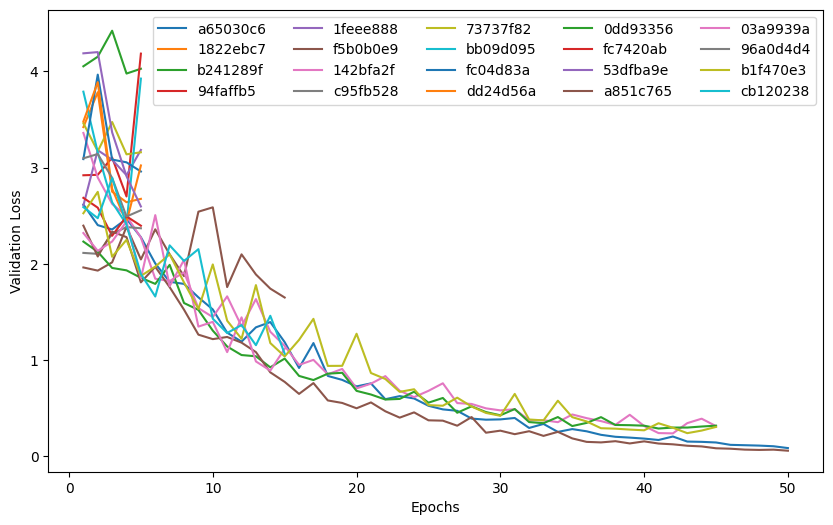

In [10]:
# Plot by epoch
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
for d in dfs.values():
    # print(d.columns)
    ax.plot(
        d.training_iteration,
        d.val_loss,
        # label=int(d.trial_id[0].split("_")[-1]),
        label=d.trial_id[0],
    )
ax.legend(ncols=5)
ax.set_xlabel("Epochs")
ax.set_ylabel("Validation Loss")

Trial: 2e3d1f59, Loss: 0.013060961908195168
Config: /Users/nwimer/ray_results/tune_model_2024-09-26_16-42-34/tune_model_2e3d1f59_887_act_fun=relu,arch_type=ann,batch_norm=False,chk_int=25,dropout=0.0500,epochs=200,input_dropout=0.0000,l2_r_2024-09-26_17-05-52
Trial: d8636a67, Loss: 0.013070405460894108
Config: /Users/nwimer/ray_results/tune_model_2024-09-26_16-42-34/tune_model_d8636a67_874_act_fun=relu,arch_type=ann,batch_norm=False,chk_int=25,dropout=0.0500,epochs=200,input_dropout=0.0000,l2_r_2024-09-26_17-05-30
Trial: ddf8aab1, Loss: 0.013073942041955888
Config: /Users/nwimer/ray_results/tune_model_2024-09-26_16-42-34/tune_model_ddf8aab1_567_act_fun=relu,arch_type=ann,batch_norm=False,chk_int=25,dropout=0.0500,epochs=200,input_dropout=0.0000,l2_r_2024-09-26_16-57-21
Trial: 4f7d4e96, Loss: 0.013398337992839515
Config: /Users/nwimer/ray_results/tune_model_2024-09-26_16-42-34/tune_model_4f7d4e96_884_act_fun=relu,arch_type=ann,batch_norm=False,chk_int=25,dropout=0.0500,epochs=200,input_

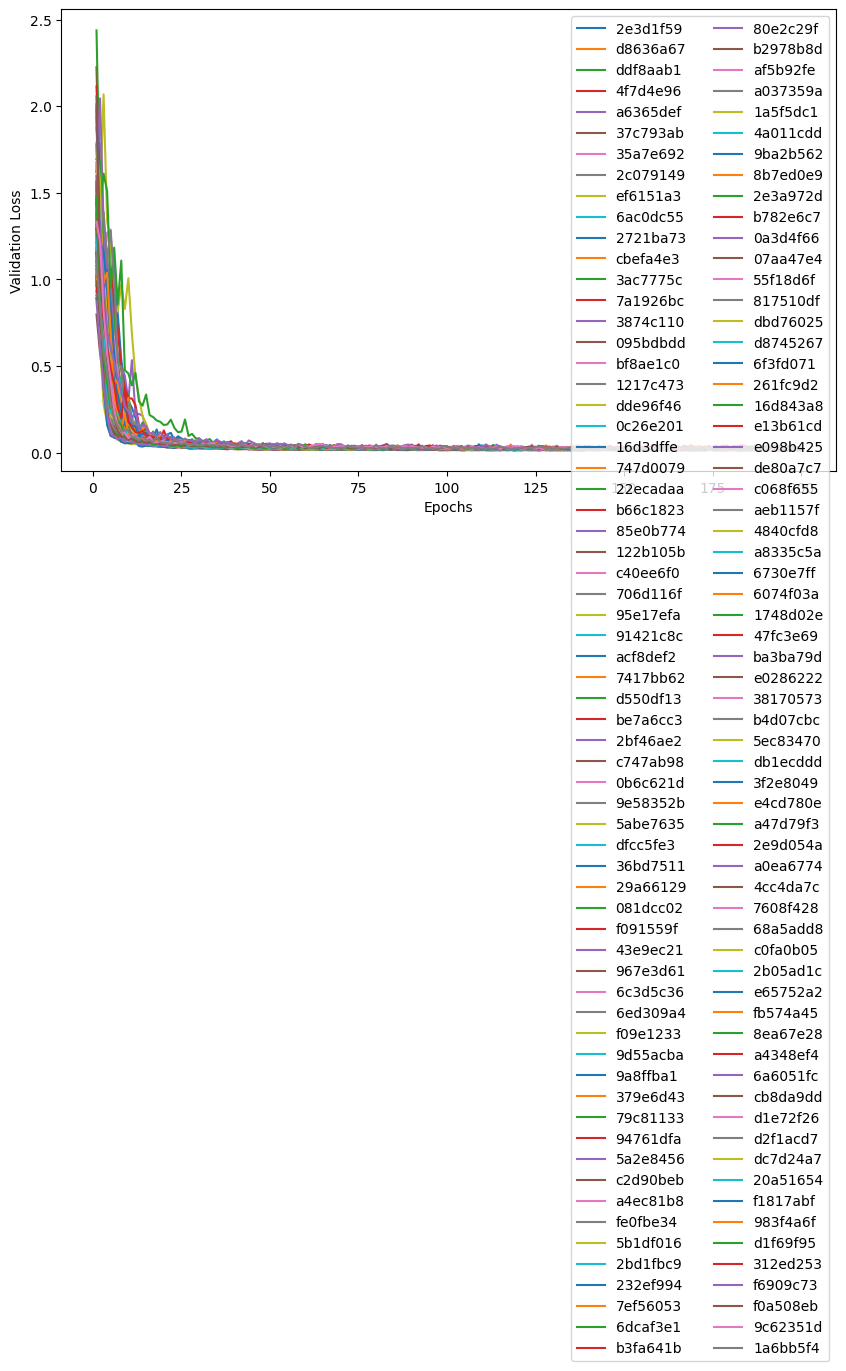

In [ ]:
# plot the top performers
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
for d_path in top_paths:
    d = dfs[d_path]
    ax.plot(
        d.training_iteration,
        d.val_loss,
        # label=int(d.trial_id[0].split("_")[-1]),
        label=d.trial_id[0],
    )
    print(f"Trial: {d.trial_id[0].split('_')[-1]}, Loss: {d.val_loss.min()}")
    print(f"Config: {d_path}")

ax.legend(ncols=2)
ax.set_xlabel("Epochs")
ax.set_ylabel("Validation Loss")

# Get the best trial
best_trial = top_paths[0]

In [11]:
best_config = hpo_result.best_config
best_hyperparameters = hpo_result.best_hyperparameters

print("Best config found was:", best_config)
print("Best searched hyperparameters were:", best_hyperparameters)
print("Metric details:", hpo_result.metric_details)

Best config found was: {'loss_fn': 'mse', 'num_features': 10, 'num_outputs': 3, 'epochs': 50, 'arch_type': 'ann', 'learning_rate': 0.001, 'act_fun': 'tanh', 'dropout': 0.25, 'input_dropout': 0.0, 'batch_norm': True, 'l2_reg': 0.0, 'layer_0_width': 4, 'layer_1_width': 32, 'layer_2_width': 8, 'max_depth': 3, 'node_list': None}
Best searched hyperparameters were: {'arch_type': 'ann', 'learning_rate': 0.001, 'act_fun': 'tanh', 'dropout': 0.25, 'input_dropout': 0.0, 'batch_norm': True, 'l2_reg': 0.0, 'layer_0_width': 4, 'layer_1_width': 32, 'layer_2_width': 8, 'max_depth': 3, 'node_list': None}
Metric details: {'metric': 'val_loss', 'mode': 'min', 'best_metric': 0.0599429989233613, 'best_trial_path': '/Users/nwimer/ray_results/_ray_tune_trainable_2026-06-12_14-58-44/_ray_tune_trainable_a851c765_16_act_fun=tanh,arch_type=ann,batch_norm=True,dropout=0.2500,epochs=50,input_dropout=0.0000,l2_reg=0._2026-06-12_14-59-03', 'best_trial_id': 'a851c765', 'best_metrics': {'iterations': 50, 'train_loss

In [15]:
best_model, optimizer, criterion = model_builder(best_config)
print(summary(best_model, input_size=(batch_size, x_train.shape[1]), device=device))

best_model.fit(
    train_dl=dataloader,
    val_dl=dataloader_val,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=200,
    device=device,
    verbose=True,
)

Layer (type:depth-idx)                   Output Shape              Param #
ArtificialNeuralNetwork                  [32, 3]                   --
├─ModuleDict: 1-1                        --                        --
│    └─DenseBlock: 2-1                   [32, 10]                  --
│    └─DefaultOutput: 2-2                [32, 3]                   --
│    │    └─Linear: 3-1                  [32, 3]                   33
│    │    └─Identity: 3-2                [32, 3]                   --
Total params: 33
Trainable params: 33
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00


 11%|█         | 22/200 [00:00<00:00, 216.52it/s]

Epoch 10, Loss: 1.1721, Val Loss: 1.1967, LR: 1.0000e-03
Epoch 20, Loss: 0.5306, Val Loss: 0.5564, LR: 1.0000e-03
Epoch 30, Loss: 0.2418, Val Loss: 0.2413, LR: 1.0000e-03
Epoch 40, Loss: 0.1142, Val Loss: 0.1434, LR: 1.0000e-03


 23%|██▎       | 46/200 [00:00<00:00, 224.90it/s]

Epoch 50, Loss: 0.0575, Val Loss: 0.0616, LR: 1.0000e-03


...

Epoch 110, Loss: 0.0146, Val Loss: 0.0146, LR: 1.0000e-03
Epoch 120, Loss: 0.0145, Val Loss: 0.0141, LR: 1.0000e-03
Epoch 130, Loss: 0.0145, Val Loss: 0.0140, LR: 1.0000e-03
Epoch 140, Loss: 0.0145, Val Loss: 0.0150, LR: 1.0000e-03
Epoch 150, Loss: 0.0145, Val Loss: 0.0178, LR: 1.0000e-03


 92%|█████████▏| 184/200 [00:00<00:00, 223.73it/s]

Epoch 160, Loss: 0.0145, Val Loss: 0.0153, LR: 1.0000e-03
Epoch 170, Loss: 0.0146, Val Loss: 0.0147, LR: 1.0000e-03
Epoch 180, Loss: 0.0145, Val Loss: 0.0133, LR: 1.0000e-03
Epoch 190, Loss: 0.0146, Val Loss: 0.0134, LR: 1.0000e-03


100%|██████████| 200/200 [00:00<00:00, 222.44it/s]

Epoch 200, Loss: 0.0146, Val Loss: 0.0156, LR: 1.0000e-03


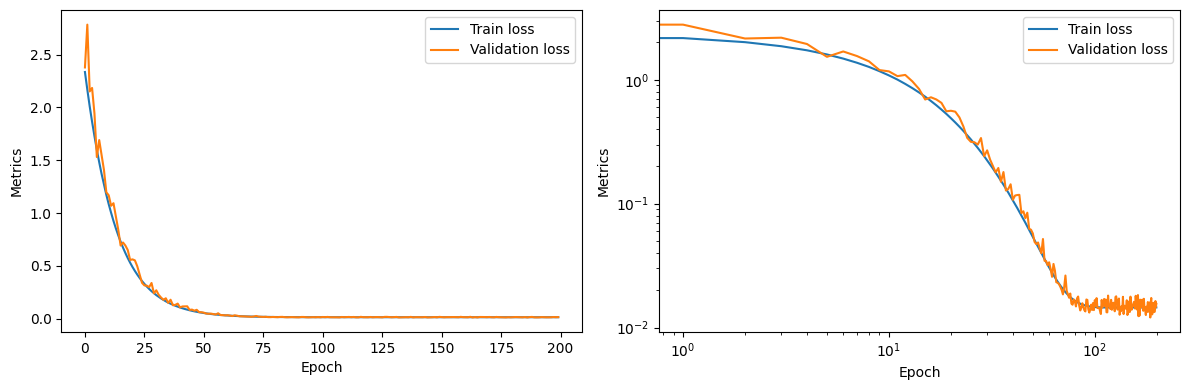

In [16]:
from ptmelt.utils.visualization import plot_history

history = best_model.history
plot_history(history, plot_log=True)

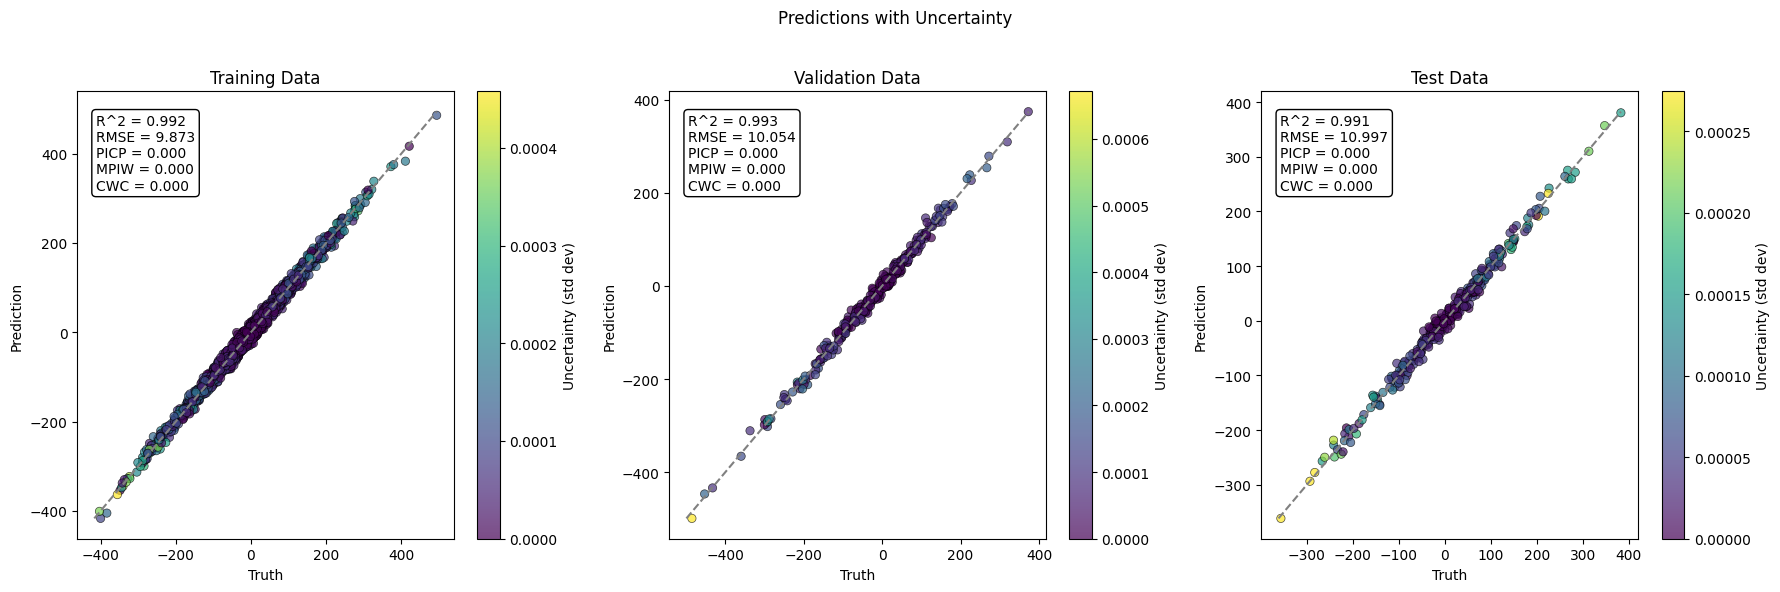

In [17]:
from ptmelt.utils.evaluation import ensemble_predictions
from ptmelt.utils.visualization import plot_predictions_with_uncertainty

# Necessary to be consistent with pt-melt prediction routines
best_model.num_mixtures = 0
ensmeble_size = 100
training = True  # needed for monte carlo dropout evaluation
####

pred_mean_train, pred_std_train = ensemble_predictions(
    best_model,
    x_train,
    y_normalizer,
    unnormalize=True,
    n_iter=ensmeble_size,
    training=training,
)
pred_mean_test, pred_std_test = ensemble_predictions(
    best_model,
    x_test,
    y_normalizer,
    unnormalize=True,
    n_iter=ensmeble_size,
    training=training,
)
pred_mean_val, pred_std_val = ensemble_predictions(
    best_model,
    x_val,
    y_normalizer,
    unnormalize=True,
    n_iter=ensmeble_size,
    training=training,
)

plot_predictions_with_uncertainty(
    pred_mean_train,
    pred_std_train,
    y_train_real,
    pred_mean_val,
    pred_std_val,
    y_val_real,
    pred_mean_test,
    pred_std_test,
    y_test_real,
    metrics_to_display=["R^2", "RMSE", "PICP", "MPIW", "CWC"],
)